Objective:
Use historical stock data to predict the next day&#39;s closing price.

Import Important Libraries

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

Fetching Data

Choosing a 2-year window (2022-2024) provides a balanced mix of market volatility and growth trends, allowing the model to capture diverse price movements.

In [3]:
# Fetching Apple stock data
ticker = 'AAPL'
data = yf.download(ticker, start="2022-01-01", end="2024-01-01")

# Inspect the first few rows
print(f"Successfully fetched data for {ticker}")
data.head()

[*********************100%***********************]  1 of 1 completed

Successfully fetched data for AAPL


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103668,178.955006,173.895967,174.013387,104487900
2022-01-04,175.843246,179.013714,175.275693,178.710370,99310400
2022-01-05,171.165848,176.303172,170.891858,175.755193,94537600
2022-01-06,168.308502,171.537680,167.956228,168.993476,96904000
2022-01-07,168.474854,170.402574,167.359321,169.179402,86709100


Exploratory Data Analysis (EDA)

Visualizing the Closing Price Trend

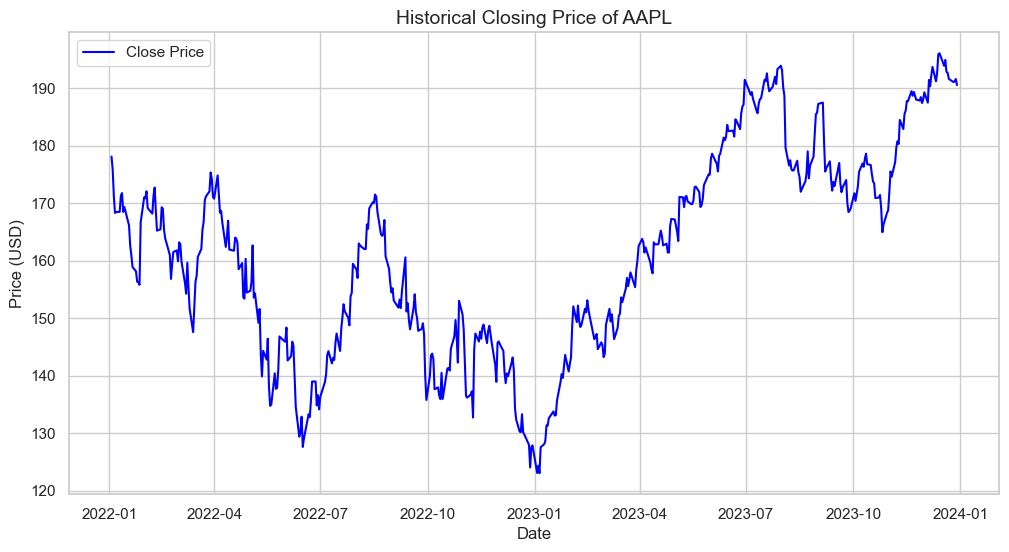

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label='Close Price', color='blue')
plt.title(f'Historical Closing Price of {ticker}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

Visualizing Trading Volume

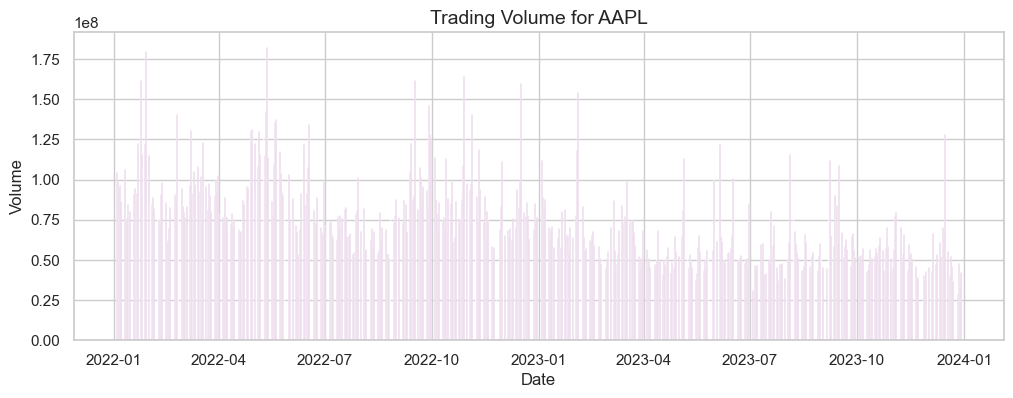

In [5]:
# Flattening the MultiIndex columns if they exist
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Now try the Volume Plot again
plt.figure(figsize=(12, 4))
plt.bar(data.index, data['Volume'], color='purple', alpha=0.7)
plt.title(f'Trading Volume for {ticker}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

In [6]:
# Create the target variable: Yesterday's features will predict Today's Close
data['Target_Close'] = data['Close'].shift(-1)

# Drop the last row because it won't have a target price for 'tomorrow'
df_model = data.dropna()

# Selecting our features
features = ['Open', 'High', 'Low', 'Volume']
X = df_model[features]
y = df_model['Target_Close']

print("Feature Engineering complete. Data is 'shifted' for next-day prediction.")

Feature Engineering complete. Data is 'shifted' for next-day prediction.


Correlation Analysis

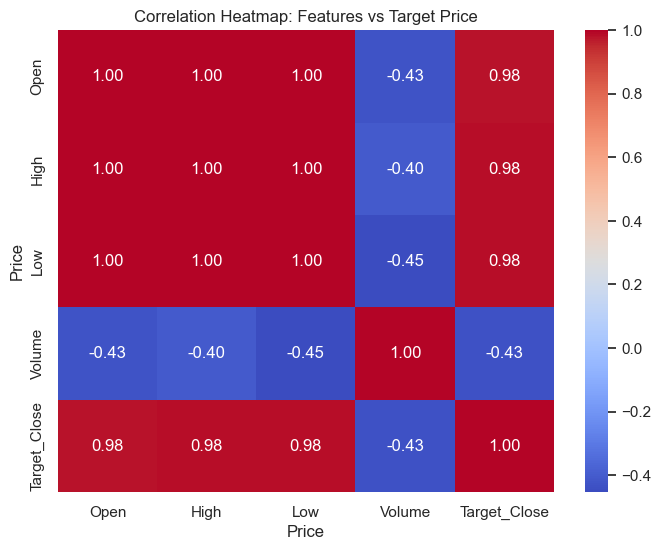

In [7]:
plt.figure(figsize=(8, 6))
# Calculate correlation between features and our target
correlation_matrix = df_model[features + ['Target_Close']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Features vs Target Price")
plt.show()

 The heatmap shows a very high correlation (near $1.00$) between the previous day's Price features (Open, High, Low) and the next day's Target_Close. This suggests that Linear Regression is a strong starting model for this prediction task.

Data Splitting

In [8]:
# Splitting the data: 80% for training and 20% for testing
# We set shuffle=False because stock data is time-dependent (order matters)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 400
Testing set size: 100


Training the LinearReression Model

In [9]:
# Initialize the model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

print("Model Training Complete.")
print(f"Model Intercept: {model.intercept_}")
print(f"Model Coefficients: {model.coef_}")

Model Training Complete.
Model Intercept: 4.20435363939049
Model Coefficients: [-8.09726773e-01  6.36312933e-01  1.14883559e+00  7.30102856e-09]


Training the Random Forest Model

In [10]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest model
# n_estimators=100 means we are using 100 decision trees
# random_state=42 ensures your results are reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Training Complete.")

Random Forest Training Complete.


The "Comparison" Visualization

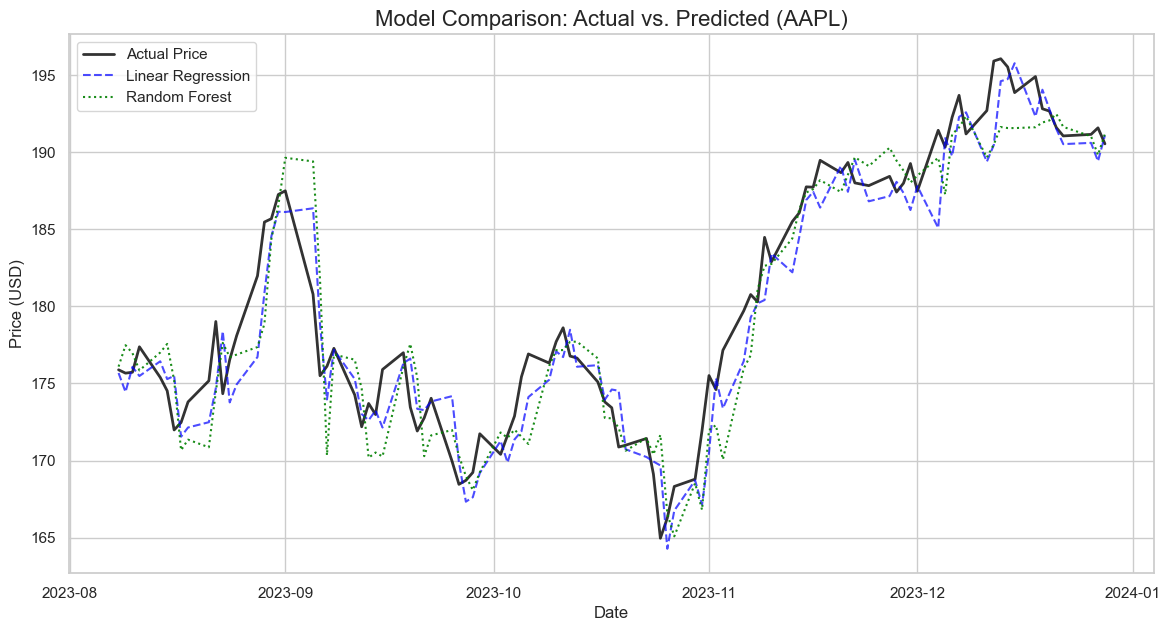

In [11]:
plt.figure(figsize=(14, 7))

# Plotting all three lines
plt.plot(y_test.index, y_test, label='Actual Price', color='black', linewidth=2, alpha=0.8)
plt.plot(y_test.index, y_pred, label='Linear Regression', color='blue', linestyle='--', alpha=0.7)
plt.plot(y_test.index, y_pred_rf, label='Random Forest', color='green', linestyle=':', alpha=0.9)

plt.title(f'Model Comparison: Actual vs. Predicted ({ticker})', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

Performance Comparison Table

In [12]:
# Linear Regression Metrics
mse_lr = mean_squared_error(y_test, y_pred)
r2_lr = r2_score(y_test, y_pred)

# Random Forest Metrics
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Create a summary table
metrics_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MSE': [mse_lr, mse_rf],
    'R2 Score': [r2_lr, r2_rf]
})

print(metrics_summary)

               Model       MSE  R2 Score
0  Linear Regression  5.724224  0.917838
1      Random Forest  8.111594  0.883572


While the Random Forest model is more complex, Linear Regression showed higher accuracy ($R^2 = 0.9178$) for this specific stock. This indicates that the price movement for this period was highly linear and driven by momentum, which a simple regression model captures more effectively than an ensemble-based approach.